# 06 Fair Refinement on PV2 + M5 Unseen Diagnostics

This notebook does all key DS steps in one place:

1. Equal-budget refinement for each ML model on `PV2`
2. Fair model selection on `PV2` test
3. Unseen transfer comparison on `M5` for selected ML models
4. Diagnostics: bias/variance proxies, horizon degradation, model matrices

Use this notebook after:
- `00c_realistic_fg_rm_generation_v2.ipynb`
- `00d_v2_data_eda_and_seasonality.ipynb`


In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling')
SCRIPTS = ROOT / 'scripts'
REPORTS = ROOT / 'outputs' / 'reports'
GENERATED = ROOT / 'outputs' / 'generated'
M5_DIR = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/external-data/m5-forecasting-accuracy')

TRAIN_SCRIPT = SCRIPTS / 'train_and_save_models.py'
TRANSFER_SCRIPT = SCRIPTS / 'm5_saved_artifact_transfer.py'

assert TRAIN_SCRIPT.exists(), f'Missing script: {TRAIN_SCRIPT}'
assert TRANSFER_SCRIPT.exists(), f'Missing script: {TRANSFER_SCRIPT}'
assert (GENERATED / 'p_v2_portable_monthly.csv').exists(), 'Missing p_v2 dataset. Run notebook 00c first.'

REPORTS.mkdir(parents=True, exist_ok=True)
print('ROOT:', ROOT)

ROOT: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling


In [2]:
# Runtime controls
RUN_PIPELINE = True  # set False to load existing outputs only
M5_SAMPLE_SERIES = 300  # set None for full dataset (slower)

# Equal-budget refinement search space
DATASET_KEY = 'PV2'
HORIZONS = '1,2,3,4,5,6,7,8,9,10,11,12'
ML_MODELS = ['XGBOOST', 'CATBOOST', 'LIGHTGBM', 'RANDOM_FOREST']
FEATURE_PROFILES = ['lags_roll_seasonal', 'lags_roll_seasonal_category', 'full']
CLASSICAL_MODELS = ['ETS', 'ARIMA', 'SARIMA']

TAG_CLASSICAL = 'pv2_classical_base'
TAG_PREFIX = 'pv2_refine'
TAG_M5_RAW = 'pv2_m5_unseen_raw'
TAG_M5_CAP = 'pv2_m5_unseen_capped'

print('RUN_PIPELINE=', RUN_PIPELINE)

RUN_PIPELINE= True


In [3]:
def run_cmd(cmd):
    print('RUNNING:', ' '.join(str(x) for x in cmd))
    subprocess.run(cmd, check=True)

def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')
    return pd.read_csv(path)

## A) Run Equal-Budget Refinement (Optional Execution)

In [ ]:
if RUN_PIPELINE:
    # Classical baseline run (single shared run)
    cmd = [
        sys.executable, str(TRAIN_SCRIPT),
        '--datasets', DATASET_KEY,
        '--classical-models', *CLASSICAL_MODELS,
        '--skip-boosting',
        '--tag', TAG_CLASSICAL,
    ]
    run_cmd(cmd)

    # ML equal-budget search: same profile set for each model
    for model in ML_MODELS:
        for profile in FEATURE_PROFILES:
            tag = f'{TAG_PREFIX}_{model.lower()}_{profile}'
            cmd = [
                sys.executable, str(TRAIN_SCRIPT),
                '--datasets', DATASET_KEY,
                '--skip-classical',
                '--boosting-models', model,
                '--feature-profile', profile,
                '--horizons', HORIZONS,
                '--tag', tag,
            ]
            run_cmd(cmd)

    # M5 unseen transfer, raw and capped, same model set
    base_m5_cmd = [
        sys.executable, str(TRANSFER_SCRIPT),
        '--m5-dir', str(M5_DIR),
        '--granularity', 'dept_store',
        '--datasets', DATASET_KEY,
        '--models', *ML_MODELS,
        '--horizons', HORIZONS,
    ]
    if M5_SAMPLE_SERIES is not None:
        base_m5_cmd.extend(['--sample-series', str(M5_SAMPLE_SERIES)])

    run_cmd(base_m5_cmd + ['--tag', TAG_M5_RAW, '--calibration', 'none'])
    run_cmd(base_m5_cmd + [
        '--tag', TAG_M5_CAP,
        '--calibration', 'recent_level_auto_capped',
        '--calibration-max-weight', '0.8',
        '--calibration-max-weight-short', '0.85',
        '--calibration-max-weight-long', '0.9',
        '--calibration-long-horizon-start', '9',
    ])
else:
    print('RUN_PIPELINE=False -> loading existing outputs only')

RUNNING: /opt/anaconda3/envs/dashboard-project/bin/python /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/scripts/train_and_save_models.py --datasets PV2 --classical-models ETS ARIMA SARIMA --skip-boosting --tag pv2_classical_base


## B) Fair Model Selection on PV2 Test

In [ ]:
classical_lb_path = REPORTS / f'{TAG_CLASSICAL}_leaderboard.csv'
classical_lb = read_csv_required(classical_lb_path)
classical_lb = classical_lb[classical_lb['dataset'] == DATASET_KEY].copy()

ml_candidates = []
for model in ML_MODELS:
    for profile in FEATURE_PROFILES:
        tag = f'{TAG_PREFIX}_{model.lower()}_{profile}'
        path = REPORTS / f'{tag}_leaderboard.csv'
        if path.exists():
            df = pd.read_csv(path)
            df = df[df['dataset'] == DATASET_KEY].copy()
            if not df.empty:
                df['tag'] = tag
                df['feature_profile'] = profile
                ml_candidates.append(df)

if not ml_candidates:
    raise FileNotFoundError('No PV2 ML refinement leaderboards found. Set RUN_PIPELINE=True and rerun.')

ml_candidates = pd.concat(ml_candidates, ignore_index=True)
best_ml = (
    ml_candidates.sort_values(['model', 'WAPE', 'MASE_mean', 'RMSE'])
    .groupby('model', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_classical = (
    classical_lb.sort_values(['model', 'WAPE', 'MASE_mean', 'RMSE'])
    .groupby('model', as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_classical['tag'] = TAG_CLASSICAL
best_classical['feature_profile'] = 'classical'

pv2_fair = pd.concat([best_classical, best_ml], ignore_index=True)
pv2_fair = pv2_fair.sort_values(['WAPE', 'MASE_mean', 'RMSE']).reset_index(drop=True)
pv2_fair[['model', 'feature_profile', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'wQL50', 'under_forecast_rate', 'tag']]

,model,feature_profile,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate,tag
0,CATBOOST,lags_roll_seasonal_category,0.193944,465.607994,-31.215974,0.916691,172.679002,0.488715,pv2_refine_catboost_lags_roll_seasonal_category
1,RANDOM_FOREST,lags_roll_seasonal_category,0.204532,492.210387,-14.738913,0.960206,182.105773,0.477069,pv2_refine_random_forest_lags_roll_seasonal_ca...
2,ARIMA,classical,0.205663,506.522393,-60.841999,0.972827,183.112624,0.513021,pv2_classical_base
3,XGBOOST,lags_roll_seasonal_category,0.207437,496.854692,-20.958560,0.972814,184.692535,0.493128,pv2_refine_xgboost_lags_roll_seasonal_category
4,LIGHTGBM,lags_roll_seasonal_category,0.214878,512.654683,-15.626508,1.013045,191.317852,0.486834,pv2_refine_lightgbm_lags_roll_seasonal_category
5,ETS,classical,0.245244,580.739857,-86.640369,1.166462,218.353999,0.545139,pv2_classical_base
6,SARIMA,classical,0.275878,670.236178,-20.553786,1.306188,245.628896,0.537326,pv2_classical_base


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_68146/1469191571.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pv2_fair, x='model', y='WAPE', palette='viridis')


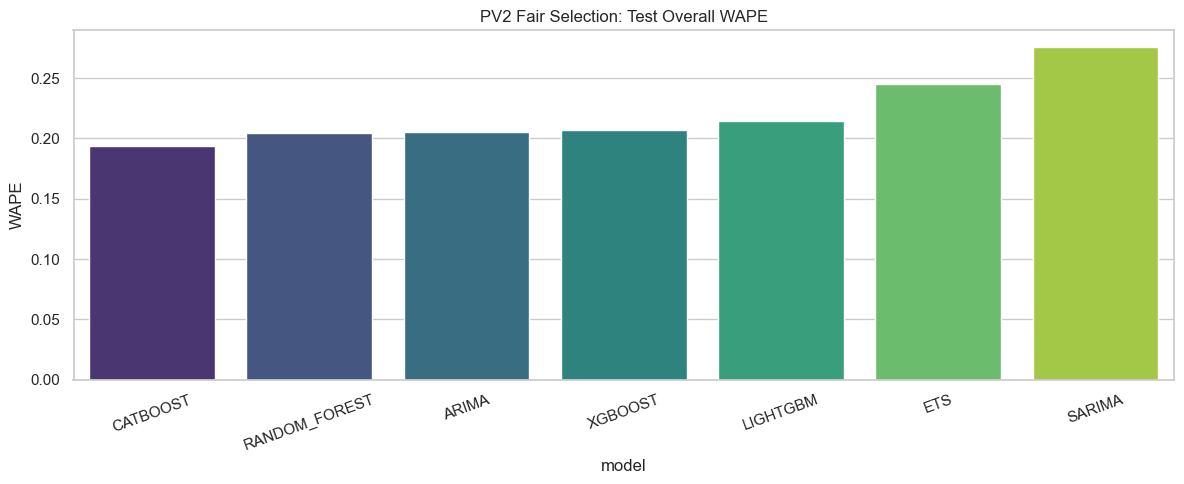

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_68146/1469191571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pv2_fair, x='model', y='RMSE', palette='magma')


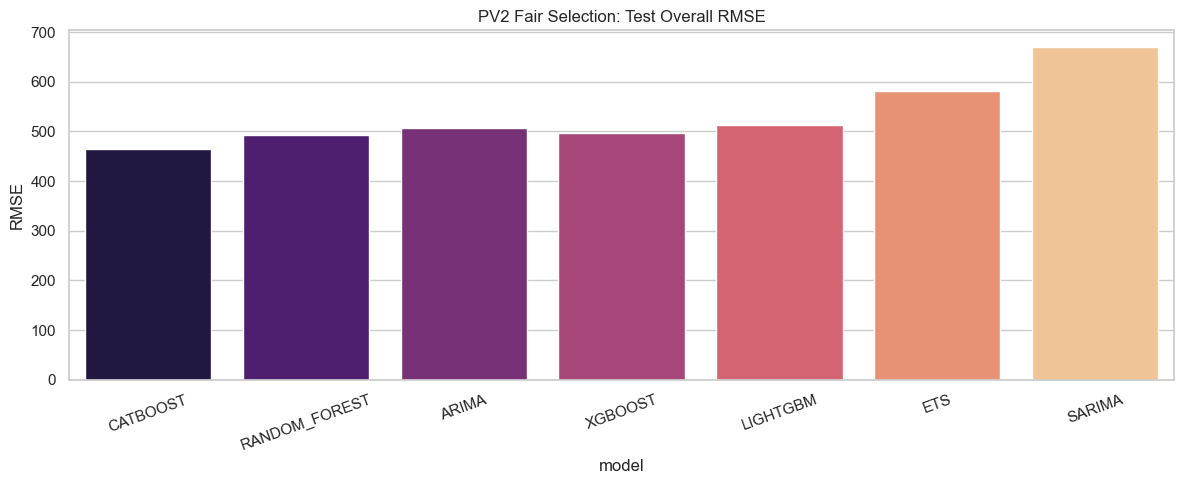

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=pv2_fair, x='model', y='WAPE', palette='viridis')
plt.title('PV2 Fair Selection: Test Overall WAPE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=pv2_fair, x='model', y='RMSE', palette='magma')
plt.title('PV2 Fair Selection: Test Overall RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

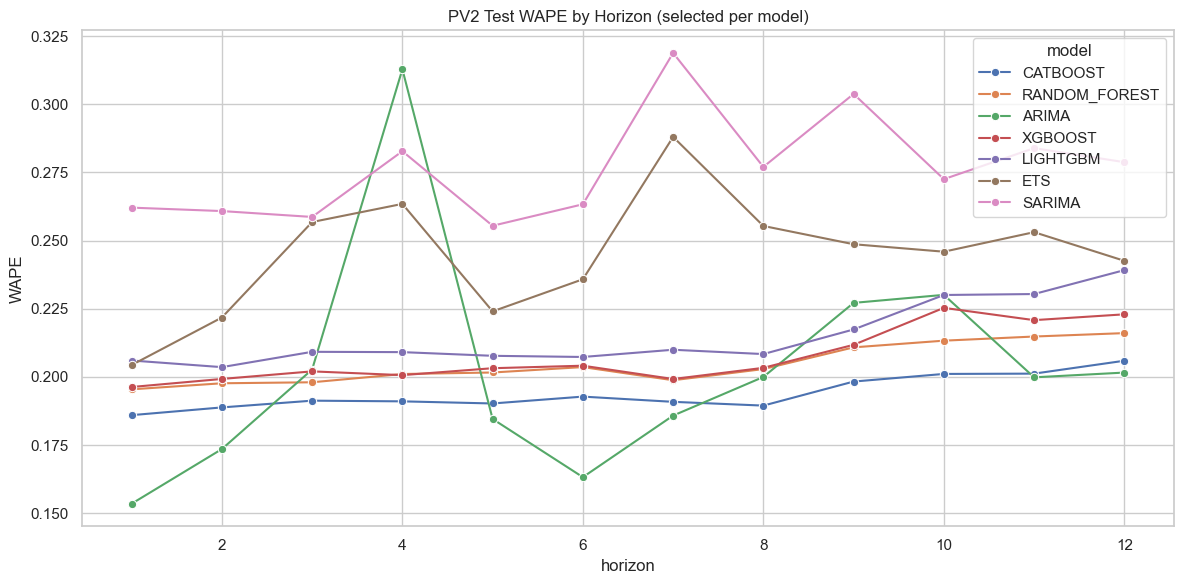

In [ ]:
# Horizon degradation plot using selected tag per model
h_rows = []
for r in pv2_fair.itertuples(index=False):
    mpath = REPORTS / f'{r.tag}_{DATASET_KEY.lower()}_metrics.csv'
    if not mpath.exists():
        continue
    m = pd.read_csv(mpath)
    s = m[(m['split'] == 'test') & (m['model'] == r.model) & (m['horizon'] > 0)].copy()
    if s.empty:
        continue
    s['selected_profile'] = r.feature_profile
    h_rows.append(s)

if h_rows:
    h_all = pd.concat(h_rows, ignore_index=True)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=h_all, x='horizon', y='WAPE', hue='model', marker='o')
    plt.title('PV2 Test WAPE by Horizon (selected per model)')
    plt.tight_layout()
    plt.show()
else:
    print('No horizon-level metrics found.')

## C) Bias-Variance Proxy Diagnostics on PV2 Test

In [ ]:
diag_rows = []
for r in pv2_fair.itertuples(index=False):
    fpath = REPORTS / f'{r.tag}_{DATASET_KEY.lower()}_forecasts.csv'
    if not fpath.exists():
        continue
    f = pd.read_csv(fpath)
    f = f[(f['split'] == 'test') & (f['model'] == r.model)].copy()
    if f.empty:
        continue
    e = f['y_pred'] - f['y_true']
    diag_rows.append({
        'model': r.model,
        'tag': r.tag,
        'mean_error_bias': float(e.mean()),
        'abs_bias': float(abs(e.mean())),
        'error_variance': float(e.var()),
        'error_std': float(e.std()),
        'rmse_from_residuals': float(np.sqrt(np.mean(np.square(e)))),
        'n_obs': int(len(f)),
    })

pv2_diag = pd.DataFrame(diag_rows).sort_values('rmse_from_residuals').reset_index(drop=True)
pv2_diag

,model,tag,mean_error_bias,abs_bias,error_variance,error_std,rmse_from_residuals,n_obs
0,CATBOOST,pv2_refine_catboost_lags_roll_seasonal_category,-31.215974,31.215974,215831.979494,464.577205,465.607994,13824
1,RANDOM_FOREST,pv2_refine_random_forest_lags_roll_seasonal_ca...,-14.738913,14.738913,242071.340435,492.007460,492.210387,13824
2,XGBOOST,pv2_refine_xgboost_lags_roll_seasonal_category,-20.958560,20.958560,246443.151024,496.430409,496.854692,13824
3,ARIMA,pv2_classical_base,-60.841999,60.841999,253082.875832,503.073430,506.522393,1152
4,LIGHTGBM,pv2_refine_lightgbm_lags_roll_seasonal_category,-15.626508,15.626508,262589.631100,512.435002,512.654683,13824
5,ETS,pv2_classical_base,-86.640369,86.640369,330038.719661,574.489965,580.739857,1152
6,SARIMA,pv2_classical_base,-20.553786,20.553786,449183.992338,670.211901,670.236178,1152


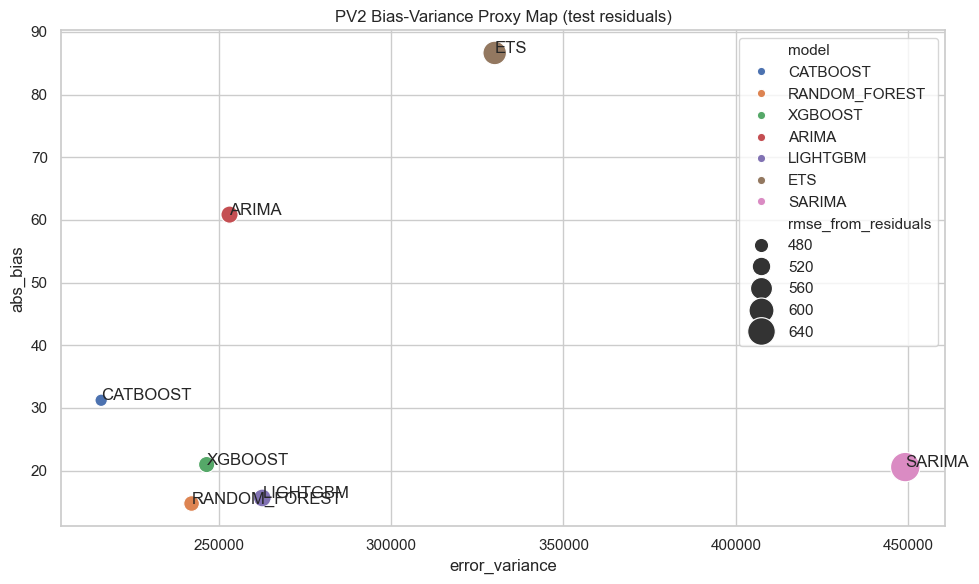

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pv2_diag,
    x='error_variance',
    y='abs_bias',
    size='rmse_from_residuals',
    hue='model',
    sizes=(80, 450),
)
for _, r in pv2_diag.iterrows():
    plt.text(r['error_variance'], r['abs_bias'], r['model'])
plt.title('PV2 Bias-Variance Proxy Map (test residuals)')
plt.tight_layout()
plt.show()

## D) M5 Unseen Transfer Comparison (selected ML models)

In [ ]:
m5_raw_path = REPORTS / f'{TAG_M5_RAW}_summary.csv'
m5_cap_path = REPORTS / f'{TAG_M5_CAP}_summary.csv'

m5_raw = read_csv_required(m5_raw_path)
m5_cap = read_csv_required(m5_cap_path)

m5_raw['mode'] = 'raw'
m5_cap['mode'] = 'auto_capped'
m5_all = pd.concat([m5_raw, m5_cap], ignore_index=True)
m5_all = m5_all[m5_all['horizon'] == 0].copy()

selected_ml = set(ML_MODELS)
m5_all['base_model'] = m5_all['model'].str.replace('_recent_level_auto_capped', '', regex=False)
m5_all = m5_all[m5_all['base_model'].isin(selected_ml)].copy()
m5_all[['base_model', 'mode', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'wQL50', 'under_forecast_rate']].sort_values(['base_model', 'mode'])

,base_model,mode,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate
7,CATBOOST,auto_capped,0.177390,4964.551281,-2672.299269,1.403208,1501.826006,0.801587
3,CATBOOST,raw,0.830701,22280.830704,-13959.247946,4.566030,7032.926639,0.884623
6,LIGHTGBM,auto_capped,0.177094,4959.125057,-2668.564413,1.395945,1499.325741,0.807440
1,LIGHTGBM,raw,0.824707,22212.105043,-13920.016037,4.369436,6982.182085,0.918750
4,RANDOM_FOREST,auto_capped,0.174800,4926.980652,-2621.709950,1.371185,1479.904331,0.801488
0,RANDOM_FOREST,raw,0.804024,21965.353998,-13574.768799,4.122405,6807.071867,0.919345
5,XGBOOST,auto_capped,0.176934,4958.312443,-2667.359142,1.392439,1497.972413,0.808730
2,XGBOOST,raw,0.824830,22233.685847,-13927.954246,4.344233,6983.219713,0.921627


In [ ]:
m5_best = (
    m5_all.sort_values(['base_model', 'WAPE', 'MASE_mean', 'RMSE'])
    .groupby('base_model', as_index=False)
    .head(1)
    .reset_index(drop=True)
)
m5_best

,dataset,model,split,horizon,n_obs,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate,mode,base_model
0,M5_TRANSFER_PV2,CATBOOST_recent_level_auto_capped,test,0,10080,0.177390,4964.551281,-2672.299269,1.403208,1501.826006,0.801587,auto_capped,CATBOOST
1,M5_TRANSFER_PV2,LIGHTGBM_recent_level_auto_capped,test,0,10080,0.177094,4959.125057,-2668.564413,1.395945,1499.325741,0.807440,auto_capped,LIGHTGBM
2,M5_TRANSFER_PV2,RANDOM_FOREST_recent_level_auto_capped,test,0,10080,0.174800,4926.980652,-2621.709950,1.371185,1479.904331,0.801488,auto_capped,RANDOM_FOREST
3,M5_TRANSFER_PV2,XGBOOST_recent_level_auto_capped,test,0,10080,0.176934,4958.312443,-2667.359142,1.392439,1497.972413,0.808730,auto_capped,XGBOOST


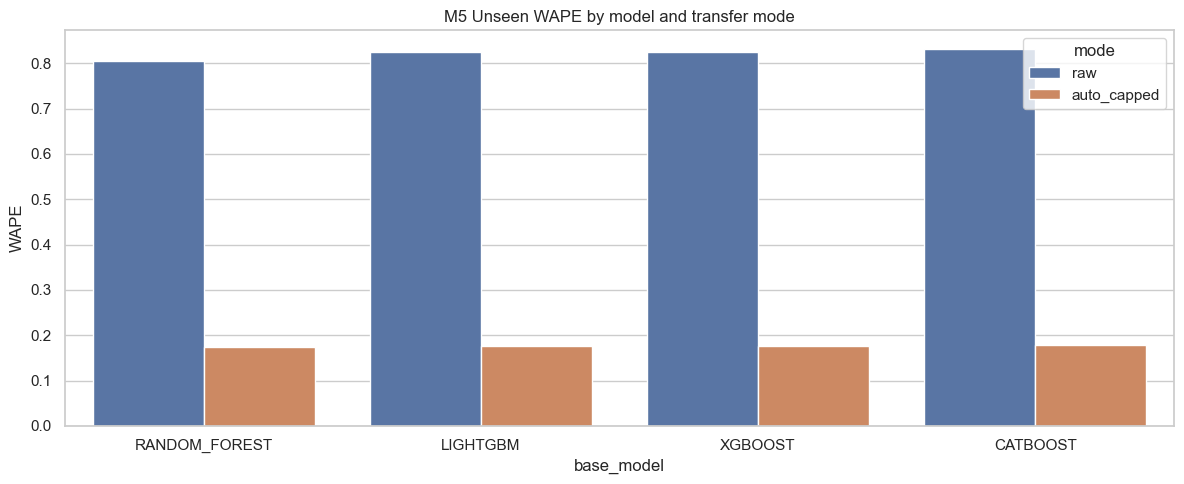

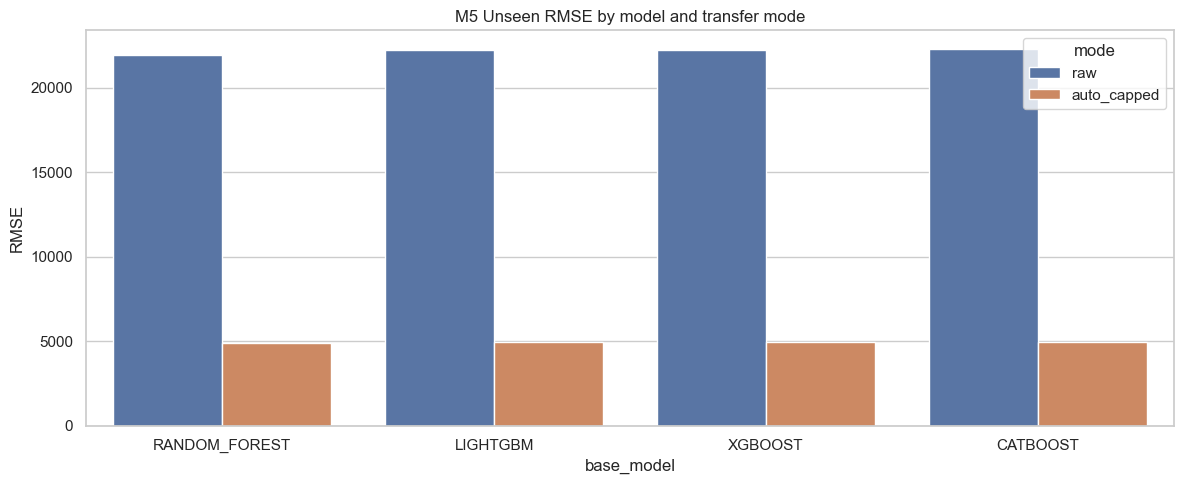

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=m5_all, x='base_model', y='WAPE', hue='mode')
plt.title('M5 Unseen WAPE by model and transfer mode')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=m5_all, x='base_model', y='RMSE', hue='mode')
plt.title('M5 Unseen RMSE by model and transfer mode')
plt.tight_layout()
plt.show()

## E) Unified Model Matrix (PV2 test vs M5 unseen)

In [ ]:
pv2_ml = pv2_fair[pv2_fair['model'].isin(ML_MODELS)].copy()
pv2_ml = pv2_ml.rename(columns={'model': 'base_model'})
pv2_ml['evaluation'] = 'PV2_test'

m5_ml = m5_best.copy()
m5_ml['evaluation'] = 'M5_unseen_best_mode'

cols = ['base_model', 'evaluation', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'wQL50', 'under_forecast_rate']
matrix = pd.concat([
    pv2_ml[cols],
    m5_ml[cols],
], ignore_index=True)

matrix.sort_values(['base_model', 'evaluation'])

,base_model,evaluation,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate
4,CATBOOST,M5_unseen_best_mode,0.177390,4964.551281,-2672.299269,1.403208,1501.826006,0.801587
0,CATBOOST,PV2_test,0.193944,465.607994,-31.215974,0.916691,172.679002,0.488715
5,LIGHTGBM,M5_unseen_best_mode,0.177094,4959.125057,-2668.564413,1.395945,1499.325741,0.807440
3,LIGHTGBM,PV2_test,0.214878,512.654683,-15.626508,1.013045,191.317852,0.486834
6,RANDOM_FOREST,M5_unseen_best_mode,0.174800,4926.980652,-2621.709950,1.371185,1479.904331,0.801488
1,RANDOM_FOREST,PV2_test,0.204532,492.210387,-14.738913,0.960206,182.105773,0.477069
7,XGBOOST,M5_unseen_best_mode,0.176934,4958.312443,-2667.359142,1.392439,1497.972413,0.808730
2,XGBOOST,PV2_test,0.207437,496.854692,-20.958560,0.972814,184.692535,0.493128


In [ ]:
gap = pv2_ml[['base_model', 'WAPE']].merge(
    m5_ml[['base_model', 'WAPE']], on='base_model', suffixes=('_pv2', '_m5')
)
gap['generalization_gap_wape'] = gap['WAPE_m5'] - gap['WAPE_pv2']
gap.sort_values('generalization_gap_wape')

,base_model,WAPE_pv2,WAPE_m5,generalization_gap_wape
3,LIGHTGBM,0.214878,0.177094,-0.037784
2,XGBOOST,0.207437,0.176934,-0.030503
1,RANDOM_FOREST,0.204532,0.174800,-0.029732
0,CATBOOST,0.193944,0.177390,-0.016555


In [ ]:
out_matrix = REPORTS / 'pv2_m5_fair_model_matrix.csv'
out_gap = REPORTS / 'pv2_m5_generalization_gap.csv'
out_pv2_diag = REPORTS / 'pv2_bias_variance_proxy.csv'

matrix.to_csv(out_matrix, index=False)
gap.to_csv(out_gap, index=False)
pv2_diag.to_csv(out_pv2_diag, index=False)

print('Saved:', out_matrix)
print('Saved:', out_gap)
print('Saved:', out_pv2_diag)

Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/pv2_m5_fair_model_matrix.csv
Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/pv2_m5_generalization_gap.csv
Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/pv2_bias_variance_proxy.csv


In [ ]:
print('PV2 strict best overall model:', pv2_fair.iloc[0]['model'])
print('M5 unseen best ML model:', m5_best.sort_values(['WAPE','MASE_mean','RMSE']).iloc[0]['base_model'])

PV2 strict best overall model: CATBOOST
M5 unseen best ML model: RANDOM_FOREST
